In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [30]:
df = pd.read_csv('./Dataset/purchase_dataset.csv')

In [32]:
df.sample(5)

,Age,Estimated_Salary,Purchased
474,43,109270,0
300,50,146189,1
20,19,102508,0
479,24,61163,1
434,53,106751,1


In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [48]:
df_scaled = scaler.fit_transform(df.iloc[:,:2])

In [52]:
df_scaled = pd.DataFrame(df_scaled, columns = df.iloc[:,:2].columns)

In [54]:
df_scaled

,Age,Estimated_Salary
0,1.368047,-0.137837
1,0.547580,-0.555185
2,-0.601074,0.105184
3,-1.175401,1.148891
4,-0.108794,0.036815
...,...,...
495,1.368047,-0.072699
496,0.793720,-0.719294
497,0.137346,1.322066
498,0.055299,-0.725755


In [63]:
np.concatenate([df_scaled, df['Purchased'].values.reshape(-1, 1)], axis=1)

array([[ 1.36804678, -0.13783711,  1.        ],
       [ 0.54757972, -0.55518487,  1.        ],
       [-0.60107417,  0.10518376,  0.        ],
       ...,
       [ 0.13734619,  1.32206615,  0.        ],
       [ 0.05529948, -0.72575526,  0.        ],
       [ 0.79371984, -1.00781874,  0.        ]])

In [67]:
df1 = np.concatenate([df_scaled, df['Purchased'].values.reshape(-1, 1)], axis=1)

In [69]:
pd.DataFrame(df1, columns = [*df.columns[:-1], 'Purchased'])

,Age,Estimated_Salary,Purchased
0,1.368047,-0.137837,1.0
1,0.547580,-0.555185,1.0
2,-0.601074,0.105184,0.0
3,-1.175401,1.148891,0.0
4,-0.108794,0.036815,1.0
...,...,...,...
495,1.368047,-0.072699,1.0
496,0.793720,-0.719294,0.0
497,0.137346,1.322066,0.0
498,0.055299,-0.725755,0.0


<function matplotlib.pyplot.show(close=None, block=None)>

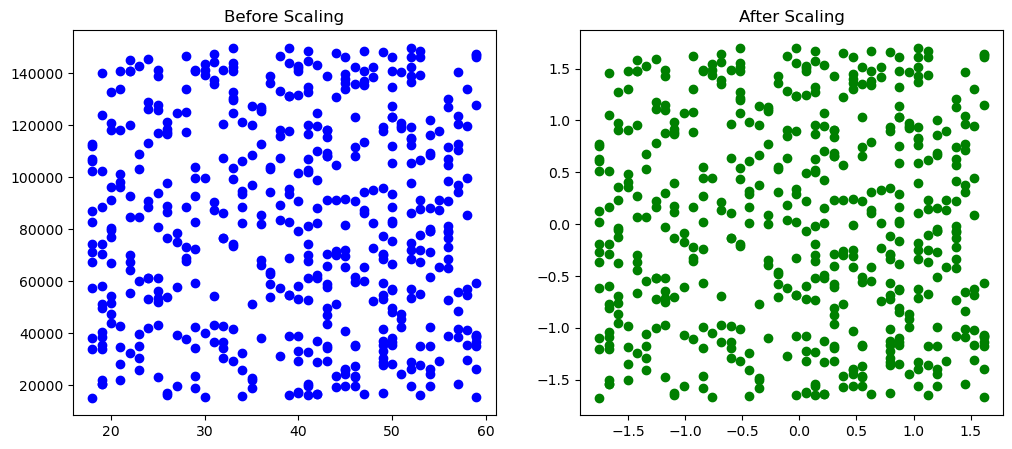

In [56]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.scatter(df['Age'], df['Estimated_Salary'], color = 'blue')
ax1.set_title('Before Scaling')
ax2.scatter(df_scaled['Age'], df_scaled['Estimated_Salary'], color = 'green')
ax2.set_title('After Scaling')
plt.show

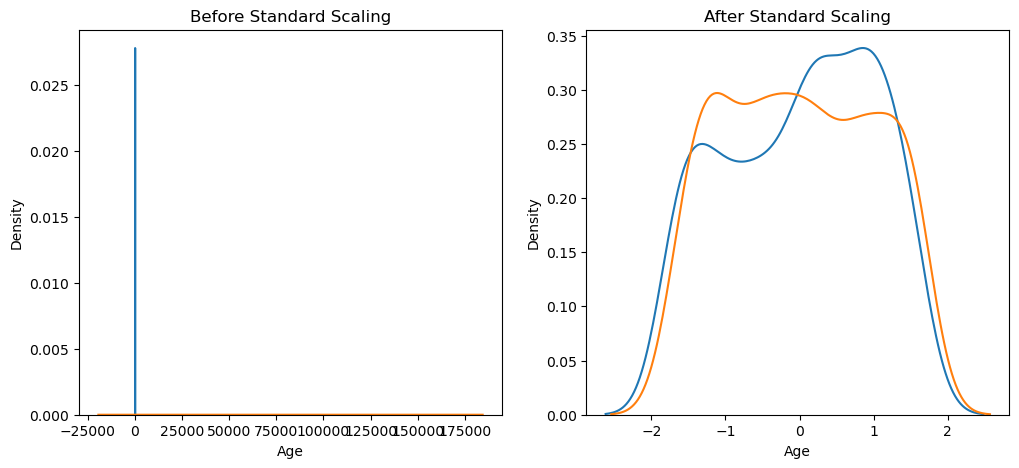

In [58]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))
ax1.set_title('Before Standard Scaling')
sns.kdeplot(df['Age'], ax=ax1)
sns.kdeplot(df['Estimated_Salary'], ax=ax1)

ax2.set_title('After Standard Scaling')
sns.kdeplot(df_scaled['Age'], ax=ax2)
sns.kdeplot(df_scaled['Estimated_Salary'], ax=ax2)
plt.show()